# A small D1Q3 collision history solved with Dalzell QLS

Xiangyu Li and coauthors linearize the lattice Boltzmann equation of a fluid and write all of its time steps as one linear system for a quantum linear solver (doi:10.1103/PhysRevResearch.7.013036). This notebook writes two time steps of the paper's single-node collision as a 15-unknown system $Ax=b$.

NWQLib's quantum linear solver (QLS) solves it in Dalzell's shortcut form (arXiv:2406.12086v2), which returns the unit direction $x/\|x\|$ of the history. The question is whether this direction resolves the small relaxation of the populations better than a history in which nothing evolves.

Install with `python -m pip install "nwqlib[aer,notebook]"`. To work on NWQLib itself, run `python -m pip install -e ".[aer,notebook]"` in a clone of the repository instead. The notebook simulates one 10-qubit circuit and runs in about 7 s on an Apple M3 Max with 36 GiB of memory (Python 3.12.14, Qiskit 2.5.2, Aer 0.17.2).

> **How to read this notebook.** The next cells solve the history and show the answer with its cost.
>
> - Sections 1 to 5: will it run, what it costs, how accurate, how large, what it assumes
> - Section 6: your own model
> - Sections 7 to 9: the paper's collision problem, its history system and the Dalzell solve
> - Section 10 and Appendix A to D: questions for extending the model, the selected construction, the weight of each time block, equation checks and the records of the run

In [1]:
from time import perf_counter

import numpy as np

from nwqlib import LinearSystem, StateVector, plan, solve
from nwqlib.algorithms import QLS

TAU = 1.0            # relaxation time of the paper's single-node D1Q3 runs (doi:10.1103/PhysRevResearch.7.013036)
DT = 0.1             # the paper's time step, tau/10 (doi:10.1103/PhysRevResearch.7.013036)
T_GUESS = 4.0        # guess t for the encoded solution norm, which Section 9 estimates as 4.2
EPSILON_INV = 0.001  # finer than the about 1% change that two Euler steps make in the normalized history

# Populations moving left, resting and moving right at one node, with density 1 and velocity 0.05.
e = np.array([-1.0, 0.0, 1.0])
weights = np.array([1.0 / 6.0, 2.0 / 3.0, 1.0 / 6.0])
rho_initial, velocity_initial = 1.0, 0.05
equilibrium = weights * rho_initial * (1.0 + 3.0 * e * velocity_initial
                                       + 4.5 * e**2 * velocity_initial**2 - 1.5 * velocity_initial**2)
initial = equilibrium + 0.02 * np.array([1.0, -2.0, 1.0])  # the perturbation changes neither density nor momentum

# Two forward-Euler steps and two copies of the final state as one history system (Section 8). Each block
# row links a time block to the preceding one, by R = (1 - DT/TAU) I for blocks 1 and 2 and by I for 3 and 4.
physical_dimension, block_count = 3, 5
block_links = np.diag([1.0 - DT / TAU, 1.0 - DT / TAU, 1.0, 1.0], k=-1)
A = np.eye(physical_dimension * block_count) - np.kron(block_links, np.eye(physical_dimension))
source_step = (DT / TAU) * equilibrium
b = np.concatenate([initial, source_step, source_step, np.zeros(6)])

started = perf_counter()
problem = LinearSystem(A=A, b=b)
method = QLS(solver="shortcut_native_svp",                     # Dalzell's shortcut (Section 9)
             encoded_solution_norm_estimate=T_GUESS, epsilon_inv=EPSILON_INV,
             block_encoding_implementation="dense_dilation")   # A as one dense unitary (Section 4)
unit = StateVector(normalization="unit", global_phase="modulo_global_phase")
selected = plan(problem, method=method, output=unit, seed=7)  # selects the construction, runs no circuit
plan_seconds = perf_counter() - started
result = solve(selected, progress=False)                      # builds and simulates the circuit
solve_seconds = perf_counter() - started - plan_seconds
direction = np.asarray(result.value)  # unit history x/‖x‖ up to a global phase, not populations

In [2]:
# Display helpers for tables, figures and the result card. They format values read from the records
# passed to them and run no plan or solve.
from html import escape

import matplotlib.pyplot as plt
from IPython.display import HTML, display

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})


def format_value(value, digits=3):
    """Round only the display to ``digits`` significant digits. Calculations and saved records keep full precision."""
    if value is None:
        return "unavailable"
    if isinstance(value, (bool, np.bool_)):
        return "Yes" if value else "No"
    if isinstance(value, (int, np.integer)):
        return f"{value:,}"
    if isinstance(value, (float, complex, np.floating, np.complexfloating)):
        return f"{value:.{digits}g}"
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (tuple, list)):
        return " / ".join(format_value(item, digits) for item in value)
    return str(value)


def format_bytes(count):
    """Show a byte count in bytes and, from one kilobyte, in kilobytes or megabytes."""
    if count >= 1e6:
        return f"{count:,} bytes ({count / 1e6:.3g} MB)"
    return f"{count:,} bytes" + (f" ({count / 1e3:.3g} kB)" if count >= 1e3 else "")


def show_table(rows, *, digits=3, details=None, headers=("Quantity", "Value", "Meaning")):
    """Display rows of computed values, optionally collapsed under a summary line."""
    body = "".join("<tr>" + "".join(
        '<td style="overflow-wrap:anywhere;text-align:left">' + escape(format_value(value, digits)) + "</td>"
        for value in row) + "</tr>" for row in rows)
    table = ('<table style="width:100%;table-layout:fixed"><thead><tr>'
             + "".join("<th>" + escape(label) + "</th>" for label in headers)
             + '</tr></thead><tbody>'
             + body + "</tbody></table>")
    if details is not None:
        table = "<details><summary>" + escape(details) + "</summary>" + table + "</details>"
    display(HTML(table))


def show_card(result, predicted, aligned_direction, reference_direction, no_evolution_direction,
              plan_seconds, solve_seconds):
    """Show the result card: the verdict, the quantum and classical cost, the comparison figure and what NWQLib did."""
    rec, trace = result.plan.reconstruction, result.data.trace
    qls_error = np.linalg.norm(aligned_direction - reference_direction)
    baseline_error = np.linalg.norm(no_evolution_direction - reference_direction)
    if qls_error < baseline_error:
        verdict = (f"The unit history that QLS returns is {baseline_error / qls_error:.2g} times closer to the Euler "
                   f"reference than a history in which nothing evolves. Its phase-aligned L2 error is "
                   f"{qls_error:.2g}, against {baseline_error:.2g}, so the solve resolves the small relaxation "
                   f"of the two time steps.")
    else:
        verdict = (f"The unit history that QLS returns is not closer to the Euler reference than a history in "
                   f"which nothing evolves. Its phase-aligned L2 error is {qls_error:.2g}, against "
                   f"{baseline_error:.2g}, so this run does not show that QLS resolves the small relaxation.")
    shots = predicted.quantity("shots").fact.value.numerator
    cx = predicted.quantity("cx").fact
    cx_text = (f"{cx.value.numerator:,} CX gates predicted before building" if cx.availability == "concrete" else
               "no CX prediction, because three blocks of this construction have no CX formula "
               "(Section 2 shows the compiled count)")
    memory_known = predicted.quantity("memory", location="host").fact.availability == "concrete"
    display(HTML(
        f"<p><strong>Result.</strong> {verdict} Execution: <code>{result.data.receipts[0].target.name}</code> "
        f"simulator, exact readout of every amplitude. Output: <code>result.value</code>, the "
        f"{rec.original_dimension}-amplitude unit history x/‖x‖ up to a global phase, not physical populations.</p>"
        f"<p><strong>Cost.</strong> Quantum: {rec.width} qubits, success probability "
        f"{result.algorithm_success_mass:.3g} per circuit run, "
        f"{'no shots (exact readout)' if shots == 0 else f'{shots:,} shots'}, {cx_text}. Classical: plan "
        f"{plan_seconds:.2f} s and solve {solve_seconds:.1f} s on this computer, {format_bytes(trace.data_bytes)} of "
        f"stored run data, planning work {trace.construction_work_reserved:,} units (a planning quantity, not "
        f"seconds){'' if memory_known else ', peak memory not predicted for this route'}.</p>"))

    coordinates = np.arange(len(reference_direction))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
    axes[0].axhline(0.0, color="0.5", linewidth=1, label="No evolution")
    axes[0].plot(coordinates, (reference_direction - no_evolution_direction).real, "o-", label="Euler reference change")
    axes[0].plot(coordinates, (aligned_direction - no_evolution_direction).real, "x--", label="QLS change")
    axes[0].set(xlabel="History coordinate", ylabel="Change in normalized amplitude, real part",
                title="Departure from no evolution")
    axes[0].legend(fontsize=8)
    axes[1].plot(coordinates, np.abs(no_evolution_direction - reference_direction), "o-",
                 color="#E69F00", label="No-evolution error")
    axes[1].plot(coordinates, np.abs(aligned_direction - reference_direction), "x--",
                 color="#0072B2", label="QLS error")
    axes[1].set(xlabel="History coordinate", ylabel="Complex amplitude error magnitude",
                title="Errors against the same Euler reference")
    axes[1].legend(fontsize=8)
    axes[2].bar(["No evolution", "QLS"], [baseline_error, qls_error], color=["#E69F00", "#0072B2"])
    axes[2].set(ylabel="Phase-aligned unit-history L2 error", title="Smaller means closer")
    for ax in axes:
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    plt.show()

    steps = (
        f"Computed the singular values of the {rec.original_dimension} × {rec.original_dimension} history matrix, "
        f"padded it to {rec.padded_dimension} coordinates and loaded A/α, with α = {rec.alpha:.3g}, as a dense block "
        f"encoding (<code>{rec.encoding_family}</code>). The encoded condition number is κ = {rec.kappa_be:.3g}.",
        f"Built Dalzell's augmented operator from the norm guess t = {rec.t:g}, selected the even kernel-reflection "
        f"polynomial of degree {rec.degree} for ε = {result.plan.method.epsilon_inv:g} and computed its "
        f"{len(rec.phase_solution)} phase angles.",
        f"Built the {rec.width}-qubit circuit and simulated it on the Aer statevector simulator.",
        f"Kept the outcome in which the ancilla qubits signal success, removed the padding coordinate and returned "
        f"the {rec.original_dimension} amplitudes as a unit vector, defined up to a global phase.",
    )
    display(HTML("<p><strong>What NWQLib did for you.</strong></p><ol>"
                 + "".join(f"<li>{step}</li>" for step in steps) + "</ol>"))

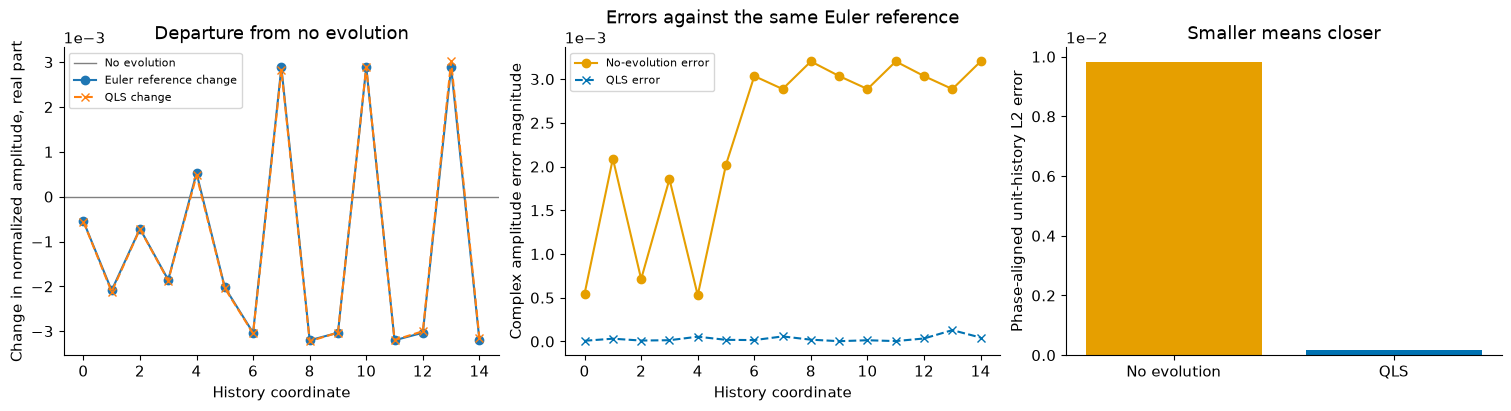

In [3]:
from nwqlib import estimate
from nwqlib.resources import ResourceContext

# Two classical histories for comparison (Section 3), the Euler reference and the no-evolution baseline.
euler_populations = equilibrium[None, :] + (1.0 - DT / TAU)**np.arange(3)[:, None] * (initial - equilibrium)[None, :]
reference_history = np.vstack([euler_populations, euler_populations[-1], euler_populations[-1]])
reference_vector = reference_history.ravel(order="C")
reference_direction = reference_vector / np.linalg.norm(reference_vector)
no_evolution_vector = np.tile(initial, block_count)
no_evolution_direction = no_evolution_vector / np.linalg.norm(no_evolution_vector)

# A global phase does not change a state, so each unit history is phase-aligned with the Euler reference first.
overlap = np.vdot(reference_direction, direction)
aligned_direction = direction * np.exp(-1j * np.angle(overlap))
direction_error = np.linalg.norm(aligned_direction - reference_direction)
fidelity = float(abs(overlap)**2)
no_evolution_overlap = np.vdot(reference_direction, no_evolution_direction)
no_evolution_direction = no_evolution_direction * np.exp(-1j * np.angle(no_evolution_overlap))
no_evolution_error = np.linalg.norm(no_evolution_direction - reference_direction)
no_evolution_fidelity = float(abs(no_evolution_overlap)**2)

predicted = estimate(selected, context=ResourceContext(basis="cx"))  # gate-count formulas only, no circuit is built
show_card(result, predicted, aligned_direction, reference_direction, no_evolution_direction, plan_seconds, solve_seconds)

**Your own model.** NWQLib takes a finished $A$ and $b$, and the collision reduction and history system are this notebook's own code (Section 6). For your own system with its physical solution, start from the template cell of the [QLS introduction](qls_linear_system_intro.ipynb).

## 1. Will it run?

**`plan` checks the system against the method's limits before anything is built.** The table shows how this history uses them.

- **Input.** A square invertible NumPy array $A$ and a vector $b$. The dense encoding loads any such matrix, at a gate count that grows steeply with its size (Section 4).
- **Output.** `result.value` is the unit direction $x/\|x\|$, defined up to a global phase. Populations, densities and momenta also need the norm $\|x\|$, which the shortcut does not return.
- **Norm guess.** The shortcut needs a guess $t$ for the encoded solution norm. A guess far from that norm lowers the success probability (Section 9).
- **Refusal.** A system beyond a limit, such as a polynomial degree above `max_degree`, is refused by `plan` with an error that names the limit. The [QLS introduction](qls_linear_system_intro.ipynb) runs one refusal and its remedy.

In [4]:
rec = selected.reconstruction
limits = result.data.trace.limits
show_table([
    ("Simulated qubits", rec.width, f"{limits.max_simulation_qubits} (local simulator default)"),
    ("Polynomial degree", rec.degree, f"{selected.method.max_degree} (max_degree)"),
    ("Simulator memory", "Not predicted for this route", f"{limits.simulator_memory_mb:,} MB (simulator_memory_mb)"),
], headers=("Limit", "This history", "Default cap"))

Limit,This history,Default cap
Simulated qubits,10,20 (local simulator default)
Polynomial degree,50,256 (max_degree)
Simulator memory,Not predicted for this route,"1,024 MB (simulator_memory_mb)"


## 2. What it costs

**The gate-count formulas give the qubits before the circuit exists, but no CX count for this construction.** The compiled circuit gives that count, and the run records the classical cost: work, stored data and time.

`estimate` adds up a gate-count formula for each block of the selected construction without building a circuit. Three blocks have no CX formula: the controlled dense-dilation query of $A$, the controlled preparation of $b$ and the multi-controlled RY rotation that loads $1/t$.

`prepare` builds the circuit without running it, and `inspect_resources` compiles a copy to CX and single-qubit gates. The formulas of this construction give no depth or T count.

In [5]:
from nwqlib import prepare

prepared = prepare(selected, progress=False)
with prepared.run:  # the prepared Run holds the circuit until the block ends
    compiled = prepared.inspect_resources(
        max_operations=10_000_000,  # the circuit has more operations than the default cap of 100,000
        transpile_options={"basis_gates": ["cx", "u"], "optimization_level": 1, "seed_transpiler": 7})
show_table([
    ("Qubits", predicted.quantity("logical_width", location="logical_device").fact.value.numerator,
     compiled["num_qubits"]),
    ("CX gates", predicted.quantity("cx").fact.value.numerator if predicted.quantity("cx").fact.availability == "concrete"
     else "Not predicted: no CX formula for three blocks", compiled["operations"].get("cx", 0)),
    ("Block applications", predicted.quantity("calls").fact.value.numerator, "Not counted"),
    ("Shots", predicted.quantity("shots").fact.value.numerator, "None: exact readout"),
    ("Success probability", "Not predicted", result.algorithm_success_mass),
    ("Single-qubit gates", "Not predicted", compiled["operations"].get("u", 0)),
    ("Depth", "Not predicted", compiled["depth"]),
], headers=("Quantum cost", "Predicted by estimate", "Compiled circuit or run"))

trace = result.data.trace
show_table([
    ("Peak memory", "Not predicted for this route", "Not recorded"),
    ("Work [units, a planning quantity, not seconds]",
     predicted.quantity("construction_work").fact.value.numerator, trace.construction_work_reserved),
    ("Stored run data", "Not predicted", format_bytes(trace.data_bytes)),
    ("Time on this computer", "Not predicted", f"plan {plan_seconds:.2f} s, solve {solve_seconds:.2f} s, "
     f"{sum(event.timing.seconds for event in trace.events):.2f} s of it in the simulator call"),
], headers=("Classical cost", "Before the run", "Recorded by the run"))

Quantum cost,Predicted by estimate,Compiled circuit or run
Qubits,10,10
CX gates,Not predicted: no CX formula for three blocks,"68,276"
Block applications,709,Not counted
Shots,0,None: exact readout
Success probability,Not predicted,0.994
Single-qubit gates,Not predicted,"98,494"
Depth,Not predicted,"128,318"


Classical cost,Before the run,Recorded by the run
Peak memory,Not predicted for this route,Not recorded
"Work [units, a planning quantity, not seconds]","37,376","1,952,672"
Stored run data,Not predicted,"145,644 bytes (146 kB)"
Time on this computer,Not predicted,"plan 0.53 s, solve 2.24 s, 1.32 s of it in the simulator call"


- **Block applications** count every call of a building block, such as the preparation of $b$, the steps of each query and the phase rotations, so they exceed the polynomial degree.
- **Work.** `estimate` counts the work of each distinct block definition once. The run records the work it counted for the Qiskit definitions it built, so the two differ.
- **Time.** The solve time includes building the circuit, the simulator call and the analysis of its output.
- **Not estimated:** peak memory on this route, physical qubits, error correction, run time on hardware and price.

## 3. How accurate?

**The QLS history is measured against the Euler reference and against a history in which nothing evolves.** The solve resolves the relaxation only if it is closer to the reference than that baseline.

High fidelity alone does not settle this. The two time steps are short, so the populations change by about one percent and even the baseline has a fidelity near one. The baseline repeats the initial populations in all five time blocks and is normalized once as a whole.

Both histories are phase-aligned with the normalized Euler reference before they are compared, because a global phase does not change a quantum state. The baseline uses no quantum circuit. Each row of the table says which kind of number it is.

In [6]:
from nwqlib.algorithms.qls import QLSVerification

image_of_direction = A @ direction
best_rhs_scale = np.vdot(b, image_of_direction) / np.vdot(b, b)
projective_residual = np.linalg.norm(image_of_direction - best_rhs_scale * b) / np.linalg.norm(image_of_direction)
spectral_check, _ = result.verify(checks=QLSVerification(comparisons=("spectral_domain",)))
spectral_facts = {item.frame.metric: item.fact.value.value for item in spectral_check.applications[0].facts}
roundoff, roundoff_reason = result.data.receipts[0].state_error()
show_table([
    ("Phase-aligned L2 error, QLS", direction_error, "Measured against reference"),
    ("Phase-aligned L2 error, no evolution", no_evolution_error, "Measured against reference"),
    ("1 − fidelity, QLS", 1 - fidelity, "Measured against reference. Fidelity is the squared overlap"),
    ("1 − fidelity, no evolution", 1 - no_evolution_fidelity, "Measured against reference"),
    ("Projective relative residual", projective_residual,
     "Measured from A and b alone (Appendix C). Zero when A times the direction is parallel to b"),
    ("Singular values outside the selected domain", spectral_facts["spectral_domain_deficit"],
     "Measured from the singular values plan computed. Zero means all are covered"),
    ("Phase-fit bound", rec.phase_error, "Upper bound for implementing the rescaled polynomial, not for the direction"),
    ("Roundoff of the simulated state", roundoff,
     "Upper bound" if roundoff is not None else "Unavailable: " + roundoff_reason),
    ("Total error of the direction from all sources", None, "Unavailable: " + selected.error_model.terms[0].formula),
], headers=("Quantity", "Value", "Kind of number"))
if direction_error < no_evolution_error:
    conclusion = ("The QLS unit history is closer to the Euler reference than the no-evolution baseline. "
                  "For these settings it improves the approximation to this relaxation, by the amount shown above.")
else:
    conclusion = ("The QLS unit history is not closer to the Euler reference than the no-evolution baseline. "
                  "This run therefore does not demonstrate that QLS resolves the small relaxation, even if its fidelity is high.")
display(HTML("<p><strong>" + escape(conclusion) + "</strong></p>"))

Quantity,Value,Kind of number
"Phase-aligned L2 error, QLS",0.00017,Measured against reference
"Phase-aligned L2 error, no evolution",0.00982,Measured against reference
"1 − fidelity, QLS",2.88e-08,Measured against reference. Fidelity is the squared overlap
"1 − fidelity, no evolution",9.64e-05,Measured against reference
Projective relative residual,0.000335,Measured from A and b alone (Appendix C). Zero when A times the direction is parallel to b
Singular values outside the selected domain,0,Measured from the singular values plan computed. Zero means all are covered
Phase-fit bound,1.17e-14,"Upper bound for implementing the rescaled polynomial, not for the direction"
Roundoff of the simulated state,unavailable,Unavailable: outside the roundoff derivation: amplitude-derived masses
Total error of the direction from all sources,unavailable,Unavailable: complete propagated physical-output error is not established


**Two settings control accuracy and success.** `EPSILON_INV` sets the degree of the reflection polynomial, and with it the number of queries to $A$. It is not a bound on the direction error. `T_GUESS` changes the success probability of each circuit run. Section 9 explains both.

## 4. How large can I go?

**The dense encoding limits this route to small systems.** It loads the $15\times15$ history matrix as a generic unitary, and each query repeats it. Its gate count grows like $4^n$ with the number $n$ of coordinate qubits.

The paper's complexity analysis (doi:10.1103/PhysRevResearch.7.013036) instead assumes an efficient oracle for the sparse, structured Carleman matrix. The blocks of the collision history are scaled identities, so a structured encoding would replace the dense query.

The `block_encoding_implementation` option of `QLS` selects among the dense, Pauli and banded encodings that NWQLib provides, where the input's structure allows them. [Planning at scale](resource_estimation_at_scale.ipynb) gives qubits and gate counts for sizes that no simulator holds.

## 5. What does it assume?

**The run is noiseless, every count is a logical count, and the model is a reduced form of the paper's.**

- **Readout.** The simulator returns every amplitude exactly. Obtaining them on hardware would require a separate readout protocol. [Local Aer](../docs/aer.md) describes noise models for the local simulator, and [Choose a backend](../docs/backends.md) lists the other backends.
- **Model.** The reduction keeps the collision and Euler trajectories of this single node. It does not reproduce the paper's Carleman calculation, which lifts the nonlinear collision to a 39-coordinate linear system, its 100-step study, or Krovi's linear-ODE algorithm (doi:10.22331/q-2023-02-02-913) used in its complexity analysis.
- **Speedup.** The small dense simulation does not establish a quantum speedup.

## 6. Your own model

NWQLib receives the finished $A$ and $b$. The reduction of the collision to three populations and the history system of Euler steps and final-state copies are this notebook's own code (Sections 7 and 8), and another fluid model needs its own.

The Dalzell shortcut returns the unit direction of the history. A study that needs populations, densities or momenta must also recover the scale of $x$. The [QLS introduction](qls_linear_system_intro.ipynb) solves your own $A$ and $b$ with the inverse polynomial, which returns the physical solution.

[Why NWQLib](../docs/why_nwqlib.md) compares this workflow with other packages.

## 7. The collision problem and why three populations suffice

The problem is the single-node D1Q3 collision, with one spatial dimension and three discrete velocities, studied in the Appendix and Fig. 2 of Xiangyu Li et al., [*Potential quantum advantage for simulation of fluid dynamics*, Physical Review Research **7**, 013036 (2025)](https://doi.org/10.1103/PhysRevResearch.7.013036).

Equation, appendix and figure numbers follow the published article. In [arXiv:2303.16550v3](https://arxiv.org/abs/2303.16550v3) its Eq. (3), Appendix and Fig. 2 are Eq. (2), Appendix A and Fig. 3.

The notebook uses the paper's relaxation time $\tau=1$ and step size $\Delta t=\tau/10$. The density $\rho_0=1$, the velocity $u_0=0.05$ and the non-equilibrium perturbation of the first code cell are choices of this notebook.

![A three-population collision becomes a small history-state problem](generators/assets/collision_small_overview.png)

The notebook reduces the collision equation with its conserved density and momentum to three physical populations. The paper's Eq. (3), with two forward-Euler steps and two final-state copies, then gives the 15-unknown linear system. For this special single node, the reduction preserves the physical collision and Euler trajectories.

The populations $f_-,f_0,f_+$ describe particles moving left, resting, and moving right. Their sum is density, and their velocity-weighted sum is momentum.

$$\rho=\sum_i f_i,\qquad j=\sum_i e_i f_i,\qquad u=j/\rho.$$

For $e=(-1,0,1)$ and $w=(1/6,2/3,1/6)$, the low-Mach equilibrium is $f_i^{\rm eq}=w_i\rho[1+3e_i u+(9/2)e_i^2u^2-(3/2)u^2]$. It has the same density and momentum as the input.

Collision redistributes these populations while conserving $\rho$ and $j$. A single periodic node has no spatial streaming, so its equilibrium stays fixed. The Bhatnagar–Gross–Krook (BGK) collision equation therefore reduces to an affine linear equation.

$$\dot f=-f/\tau+f^{\rm eq}/\tau,\qquad f(t)=f^{\rm eq}+[f(0)-f^{\rm eq}]e^{-t/\tau}.$$

This is an explicit reduction using conservation, not a new truncation of the 39-coordinate Carleman system. With $r=1-\Delta t/\tau=0.9$, forward Euler gives

$$f^{(n+1)}=r f^{(n)}+(\Delta t/\tau)f^{\rm eq},\qquad f^{(n)}=f^{\rm eq}+r^n[f(0)-f^{\rm eq}].$$

The superscript $(n)$ labels a time step for the full three-population vector. It differs from the subscript 0 in $f_0$, which labels the resting population.

**Figure 1.** The first panel shows the chosen input and equilibrium. The second shows continuous relaxation with the two Euler steps as markers, and the third the Euler time-discretization error. All curves in this figure are classical references.

Initial populations: 0.163 / 0.624 / 0.213
Initial density and momentum: 1 / 0.05


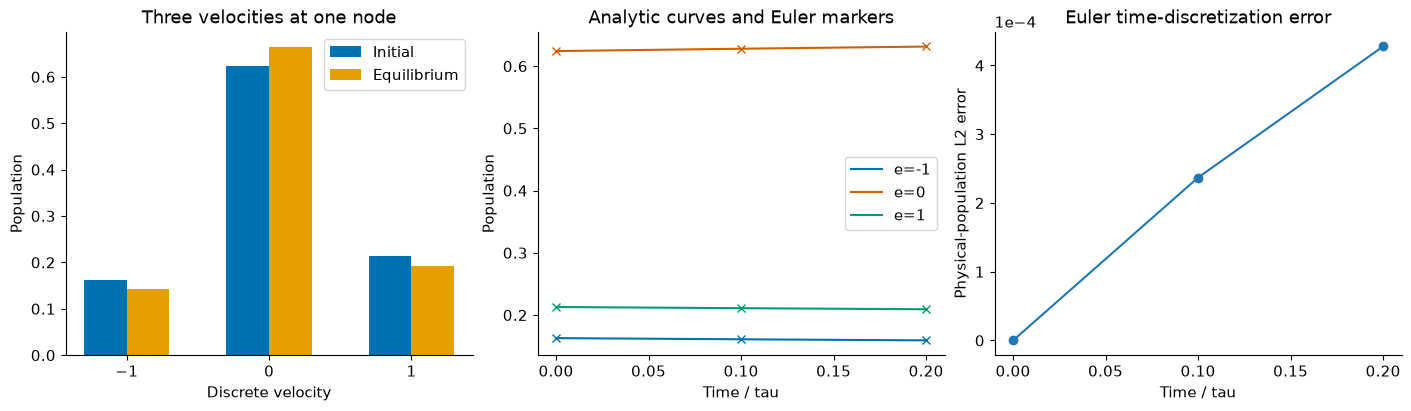

In [7]:
print("Initial populations:", format_value(initial))
print("Initial density and momentum:", format_value((initial.sum(), e @ initial)))

# Closed-form relaxation curves, independent of any linear solver.
times = np.array([0.0, DT, 2.0 * DT])
dense_times = np.linspace(0.0, times[-1], 120)
analytic_curve = equilibrium[None, :] + np.exp(-dense_times[:, None] / TAU) * (initial - equilibrium)[None, :]
analytic_at_steps = equilibrium[None, :] + np.exp(-times[:, None] / TAU) * (initial - equilibrium)[None, :]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
axes[0].bar(e - 0.15, initial, width=0.3, color="#0072B2", label="Initial")
axes[0].bar(e + 0.15, equilibrium, width=0.3, color="#E69F00", label="Equilibrium")
axes[0].set(xticks=e, xlabel="Discrete velocity", ylabel="Population", title="Three velocities at one node")
axes[0].legend()
for index, color in enumerate(("#0072B2", "#D55E00", "#009E73")):
    axes[1].plot(dense_times / TAU, analytic_curve[:, index], color=color, label=f"e={e[index]:g}")
    axes[1].plot(times / TAU, euler_populations[:, index], "x", color=color)
axes[1].set(xlabel="Time / tau", ylabel="Population", title="Analytic curves and Euler markers")
axes[1].legend()
# The norm compares three physical populations at each time, not quantum amplitudes.
axes[2].plot(times / TAU, np.linalg.norm(euler_populations - analytic_at_steps, axis=1), "o-")
axes[2].set(xlabel="Time / tau", ylabel="Physical-population L2 error", title="Euler time-discretization error")
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.show()

## 8. A 15-unknown history system

Each block contains only three physical populations. Let $R=(1-\Delta t/\tau)I_3$ and $s=(\Delta t/\tau)f^{\rm eq}$. The default inputs give $R=0.9I_3$ and $s=0.1f^{\rm eq}$. The first two off-diagonal blocks advance time. The last two copy the final populations.

$$A=\begin{pmatrix}I&0&0&0&0\\-R&I&0&0&0\\0&-R&I&0&0\\0&0&-I&I&0\\0&0&0&-I&I\end{pmatrix},\quad b=\begin{pmatrix}f(0)\\s\\s\\0\\0\end{pmatrix},\quad x=\begin{pmatrix}f^{(0)}\\f^{(1)}\\f^{(2)}\\f^{(2)}\\f^{(2)}\end{pmatrix},\quad Ax=b.$$

The source $s$ is essential. Omitting it would make all populations decay toward zero instead of the conserved equilibrium. The copies represent the same final time $t=2\Delta t$, not additional evolution. They increase the weight of the final-time sector in a normalized history state.

**Figure 2.** The matrix panel separates the five three-coordinate blocks. The diagram distinguishes time advances from final-state copies, and the right-hand-side panel shows why the two source blocks are nonzero. All three are inputs to the quantum solve. The printed residual checks that the Euler reference of the result card solves this system.

Classical history equation residual: 3.43e-17


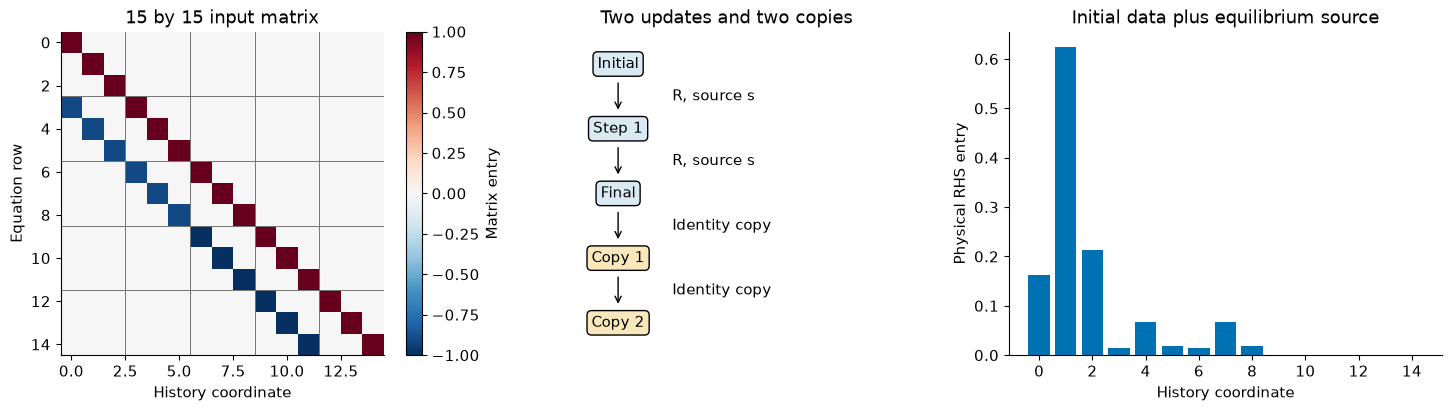

In [8]:
print("Classical history equation residual:", format_value(np.linalg.norm(A @ reference_vector - b)))
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
im = axes[0].imshow(A, cmap="RdBu_r", vmin=-1, vmax=1)
for edge in np.arange(1, block_count) * physical_dimension - 0.5:
    axes[0].axhline(edge, color="0.45", linewidth=0.7)
    axes[0].axvline(edge, color="0.45", linewidth=0.7)
axes[0].set(xlabel="History coordinate", ylabel="Equation row", title=f"{A.shape[0]} by {A.shape[1]} input matrix")
fig.colorbar(im, ax=axes[0], label="Matrix entry")
for index, label in enumerate(("Initial", "Step 1", "Final", "Copy 1", "Copy 2")):
    axes[1].text(0, -index, label, ha="center", va="center",
                 bbox={"boxstyle": "round", "facecolor": "#D9EAF4" if index < 3 else "#F9E8BC"})
    if index:
        axes[1].annotate("", xy=(0, -index + 0.25), xytext=(0, -index + 0.75), arrowprops={"arrowstyle": "->"})
        axes[1].text(0.25, -index + 0.5, "R, source s" if index <= 2 else "Identity copy", va="center")
axes[1].set(xlim=(-0.5, 1.5), ylim=(-4.5, 0.5), title="Two updates and two copies")
axes[1].axis("off")
axes[2].bar(np.arange(len(b)), b, color="#0072B2")
axes[2].set(xlabel="History coordinate", ylabel="Physical RHS entry", title="Initial data plus equilibrium source")
plt.show()

## 9. The Dalzell solve and the comparison

NWQLib's `shortcut_native_svp` implements Algorithm 1 of Dalzell's shortcut solver ([arXiv:2406.12086v2](https://arxiv.org/abs/2406.12086v2)) and returns the unit vector $|x\rangle=x/\|x\|$, up to a global phase. It does not return the physical history norm, so the comparison concerns normalized history directions, not physical population values.

`plan` in the first code cell selected the construction, and `solve` ran its one quantum circuit. The simulator returns all amplitudes.

**The norm guess.** The shortcut needs a guess $t$ for the encoded solution norm $\nu=\alpha\|x\|/\|b\|$. Here $\alpha$ is the block-encoding normalization, so the circuit encodes $A/\alpha$. The default `T_GUESS = 4` comes from an estimate $\nu\approx4.2$ made before the run, without the reference solution.

The success probability is about $\sin^2(2\theta_t)$ with $\theta_t=\arctan(\nu/t)$, largest at $t=\nu$ (Dalzell, arXiv:2406.12086v2, Eqs. (7) and (17)). A guess near 4.2 therefore makes it close to one.

<details><summary>Where the estimate ν ≈ 4.2 comes from</summary>

Two Euler steps change the populations by about one percent, so all five blocks of $x$ are close to $f(0)$. The right-hand side $b$ holds $f(0)$, two source blocks equal to one tenth of $f^{\rm eq}$ and two zero blocks.

Hence $\|x\|\approx\sqrt5\,\|b\|$ and $\nu\approx\sqrt5\,\alpha$. The dense encoding's $\alpha$ is the largest singular value of $A$, 1.88, so $\nu\approx4.2$.

</details>

**The construction parameter.** `EPSILON_INV` sets the approximation parameter of the reflection polynomial and therefore its degree. It is not a bound on the final direction error. The normalized history changes by about one percent, so the construction must be finer than that change. Appendix A lists the selected parameters, the polynomial and its phases.

**Reading the card's figure.** The left panel subtracts the no-evolution baseline to expose the small change in normalized amplitudes, shown as real parts. The middle panel shows the complex coordinate errors of QLS and the baseline against the Euler reference, and the right panel their L2 distances.

Normalizing a whole history uses all five blocks. Its initial-block amplitudes can therefore differ from the baseline even though both physical histories start from the same populations.

**The two measures.** The L2 error is zero for an identical unit direction. Fidelity is the squared overlap with the reference and equals one for an identical unit state. Fidelity can be close to one even when QLS does not improve on the baseline, because most amplitudes change little over this short interval.

The table of Section 3 therefore shows $1-\text{fidelity}$, which reveals differences that a fidelity rounded to three digits hides. The Plan and Result keep the norm guess, the polynomial and the returned data, so an accuracy shortfall can be traced to the selected construction in Appendices A to C.

## 10. Explore the model

1. Is a normalized history state the intended output, or does the application require a physical density, momentum or population value? The latter requires a physical-scale or observable-recovery design beyond this shortcut output.
2. When spatial streaming is added, which conserved-moment reduction survives, and when is the larger Carleman lift necessary?
3. Which input structure should a practical block encoding use? This example makes a dense query small enough to inspect, while the paper's scaling argument (doi:10.1103/PhysRevResearch.7.013036) assumes efficient oracle access at larger sizes.

## Appendix A. Construction and selected parameters

**The norm guess.** The method requires a numeric guess $t$ for the encoded solution norm $\nu=\|(A/\alpha)^{-1}(b/\|b\|)\|=\alpha\|x\|/\|b\|$, where $\alpha$ is the block-encoding normalization. This parameter is distinct from physical time and from the physical norm $\|x\|$.

A guess far from $\nu$ lowers the success probability (Section 9). A guess below $\nu$ also loosens Dalzell's bound on the direction error, which grows like $1/\cos\theta_t$ with $\cos\theta_t=t/\sqrt{t^2+\nu^2}$ (Dalzell, arXiv:2406.12086v2, App. C, Theorem 1, Eq. (68)). At $t=4$ this factor is 2% above its value at $t=\nu$.

**The qubits.** With the default construction, padding from 15 to 16 coordinates uses four coordinate qubits. Dense encoding adds one ancilla, the shortcut adds two working ancillas and an augmentation qubit, and the QSVT construction adds two more, for ten total.

The dense base unitary is $32\times32$ and acts on five qubits. The tables report the current selected dimensions and width.

**What `plan` computed.** `plan` performs a small SVD and selects the polynomial and its phases. The quantum circuit is constructed and executed by `solve`.

NWQLib keeps the original equation separate from its encoded representation. The original dimension tells us what the answer means, while the padded dimension and total circuit width describe the quantum representation. The padding coordinate, whose right-hand-side entry is zero, is removed when the answer is read out.

The singular values of the original matrix determine its condition number. Encoding divides the matrix by $\alpha$, so the encoded condition number is $\kappa_{\rm be}=\alpha/\sigma_{\min}$. The polynomial can use a slightly larger domain parameter. These quantities answer different questions and should not be substituted for each other.

The tables below read the selected records. The output is a unit vector modulo global phase, and recovering physical population values would also require the solution norm.

The appendix displays numbers to six significant figures, while calculations and saved records keep their full precision. The parameter table is open, and a click on a summary line opens each of the other tables.

In [9]:
show_table([
    ("Original / padded dimension", (rec.original_dimension, rec.padded_dimension), f"{rec.original_dimension} physical history entries, padded to {rec.padded_dimension}"),
    ("Encoded coordinate dimension", rec.system_dimension, "A / alpha coordinates before the Dalzell augmentation"),
    ("Encoding family / ancillas", (rec.encoding_family, rec.encoding_ancillas), "Encoding chosen for A"),
    ("Method embedding / total qubits", (rec.embedding, rec.width), "Shortcut layout and complete selected width"),
    ("Original singular interval", (rec.sigma_min, rec.sigma_max), "Numerical endpoints computed by plan"),
    ("Condition number", rec.condition_number, "Original sigma_max / sigma_min"),
    ("Encoding normalization alpha", rec.alpha, "The encoded block represents A / alpha"),
    ("Encoded / polynomial kappa", (rec.kappa_be, rec.polynomial_kappa), "Selected inverse-domain parameters"),
    ("Norm guess / source", (rec.t, rec.t_source), "User-supplied guess for the encoded solution norm"),
    ("Output normalization / phase", (selected.output.normalization, selected.output.global_phase), "Unit direction modulo global phase"),
    ("Physical recovery scale", rec.recovery, "Absent for a direction-only shortcut"),
], digits=6)
show_table([
    *[("Spectral selection: " + name.replace("_", " "), count,
       "Recorded work for obtaining the original singular endpoints")
      for name, count in rec.spectral_calls],
    ("Declared spectral method", rec.spectral_method, "How the original singular endpoints were obtained"),
], digits=6, details="Spectral selection work")

Quantity,Value,Meaning
Original / padded dimension,15 / 16,"15 physical history entries, padded to 16"
Encoded coordinate dimension,16,A / alpha coordinates before the Dalzell augmentation
Encoding family / ancillas,dense_dilation / 1,Encoding chosen for A
Method embedding / total qubits,none / 10,Shortcut layout and complete selected width
Original singular interval,0.309239 / 1.8788,Numerical endpoints computed by plan
Condition number,6.07557,Original sigma_max / sigma_min
Encoding normalization alpha,1.8788,The encoded block represents A / alpha
Encoded / polynomial kappa,6.07557 / 6.07557,Selected inverse-domain parameters
Norm guess / source,4 / user,User-supplied guess for the encoded solution norm
Output normalization / phase,unit / modulo_global_phase,Unit direction modulo global phase


Quantity,Value,Meaning
Spectral selection: svd calls,1,Recorded work for obtaining the original singular endpoints
Spectral selection: eigh calls,0,Recorded work for obtaining the original singular endpoints
Spectral selection: eigvalsh calls,0,Recorded work for obtaining the original singular endpoints
Declared spectral method,original_svd,How the original singular endpoints were obtained


### Inspect the kernel-reflection polynomial and phases

The shortcut constructs an augmented operator $G_t$ whose kernel encodes the inverse direction (Dalzell, arXiv:2406.12086v2, Eqs. (8)–(11)). An ideal reflection multiplies vectors in the kernel by $+1$ and the other singular-vector directions, whose singular values lie in the selected positive domain, by $-1$.

A finite even polynomial approximates that reflection (Dalzell, App. B.3, Eq. (62)). Its behavior in the gap between zero and the selected positive singular domain is not an accuracy claim.

The first panel plots the stored, unrescaled reflection polynomial $K(s)$. The circuit implements a bounded version $K(s)/\mathrm{rescale}$ through its selected phases. The second panel shows those stored phases in radians. The phase-fit bound applies to that rescaled polynomial action, not directly to the final normalized solution error.

Quantity,Value,Meaning
Requested construction tolerance,0.001,"Construction input, not a final direction-error guarantee"
Reflection degree / half-degree,50 / 25,Even polynomial degree is twice ell
Kernel parameter eta,0.000707107,Construction parameter derived from epsilon_inv
Polynomial rescale,1.00129,Maps the polynomial into the QSP amplitude domain
Phase count / evaluations,51 / 166,Selected angles and phase-solver work
Phase-fit bound,1.16607e-14,Available bound for implementing the rescaled polynomial
Encoding error,4.44089e-16,Bound in the quantity and metric that the selected encoding declares


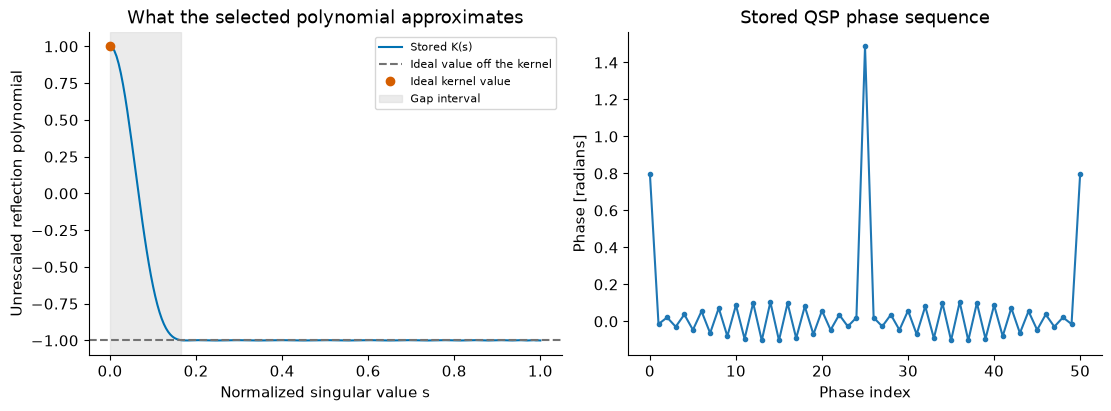

In [10]:
show_table([
    ("Requested construction tolerance", selected.method.epsilon_inv, "Construction input, not a final direction-error guarantee"),
    ("Reflection degree / half-degree", (rec.degree, rec.polynomial.ell), "Even polynomial degree is twice ell"),
    ("Kernel parameter eta", rec.polynomial.eta, "Construction parameter derived from epsilon_inv"),
    ("Polynomial rescale", rec.polynomial.rescale, "Maps the polynomial into the QSP amplitude domain"),
    ("Phase count / evaluations", (len(rec.phase_solution), rec.phase_evaluations), "Selected angles and phase-solver work"),
    ("Phase-fit bound", rec.phase_error, "Available bound for implementing the rescaled polynomial"),
    ("Encoding error", rec.encoding_error, "Bound in the quantity and metric that the selected encoding declares"),
], digits=6, details="Polynomial and phase parameters")
singular_grid = np.linspace(0.0, 1.0, 201)
reflection_values = np.polynomial.chebyshev.chebval(singular_grid, rec.polynomial.coefficients)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].plot(singular_grid, reflection_values, color="#0072B2", label="Stored K(s)")
axes[0].axhline(-1.0, color="0.45", linestyle="--", label="Ideal value off the kernel")
axes[0].plot([0], [1], "o", color="#D55E00", label="Ideal kernel value")
axes[0].axvspan(0, 1.0 / rec.polynomial_kappa, color="0.85", alpha=0.5, label="Gap interval")
axes[0].set(xlabel="Normalized singular value s", ylabel="Unrescaled reflection polynomial", title="What the selected polynomial approximates")
axes[0].legend(fontsize=8)
axes[1].plot(np.arange(len(rec.phase_solution)), rec.phase_solution, "o-", markersize=3)
axes[1].set(xlabel="Phase index", ylabel="Phase [radians]", title="Stored QSP phase sequence")
plt.show()

## Appendix B. Success mass and final-time weight

Algorithm success mass, the success probability of the result card, refers to the selected branch of the full circuit state. The following history weights are conditional on the original-coordinate unit-vector output.

The weights group every three amplitudes into one time block. The final-time sector contains blocks 2, 3 and 4, including both copies.

Fidelity $|\langle x_{\rm ref}|x_{\rm QLS}\rangle|^2$ and phase-aligned L2 error assess the unit-state result. They do not bound Euler's physical time-discretization error, which Figure 1 shows separately. Copy discrepancies compare three-amplitude blocks within the same unit history, not independently normalized copies.

**Figure 3.** The first panel compares the five conditional history weights. The second reports output discrepancies. The simulator readout is exact, so the figure has no error bars.

Aligned imaginary-part norm: 6.28842e-14
Final-time conditional weight: 0.602637
Final-copy discrepancies in the unit history: 7.7871e-05 / 0.00020415


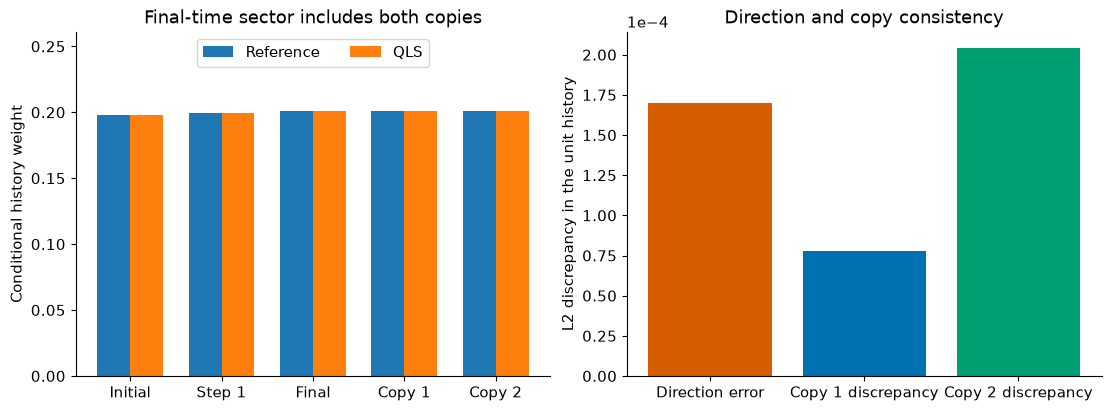

In [11]:
probabilities = np.abs(direction)**2
reference_probabilities = np.abs(reference_direction)**2
history_direction = aligned_direction.reshape(block_count, physical_dimension)
# Summing coordinate probabilities gives each time block's conditional weight.
time_weights = probabilities.reshape(block_count, physical_dimension).sum(axis=1)
reference_time_weights = reference_probabilities.reshape(block_count, physical_dimension).sum(axis=1)
copy_discrepancies = np.linalg.norm(history_direction[3:] - history_direction[2], axis=1)
print("Aligned imaginary-part norm:", format_value(np.linalg.norm(aligned_direction.imag), 6))
print("Final-time conditional weight:", format_value(time_weights[2:].sum(), 6))
print("Final-copy discrepancies in the unit history:", format_value(copy_discrepancies, 6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
blocks = np.arange(block_count)
axes[0].bar(blocks - 0.18, reference_time_weights, width=0.36, label="Reference")
axes[0].bar(blocks + 0.18, time_weights, width=0.36, label="QLS")
axes[0].set(xticks=blocks, xticklabels=["Initial", "Step 1", "Final", "Copy 1", "Copy 2"],
            ylabel="Conditional history weight", title="Final-time sector includes both copies",
            ylim=(0, 1.3 * reference_time_weights.max()))
axes[0].legend(ncol=2, loc="upper center")
axes[1].bar([0, 1, 2], [direction_error, *copy_discrepancies], color=["#D55E00", "#0072B2", "#009E73"])
axes[1].set(xticks=[0, 1, 2], xticklabels=["Direction error", "Copy 1 discrepancy", "Copy 2 discrepancy"],
            ylabel="L2 discrepancy in the unit history", title="Direction and copy consistency")
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.show()

## Appendix C. Equation checks

A unit direction need not satisfy $Ay=b$ with the original physical scaling, but its image should be proportional to $b$. Section 3 finds the best scalar $\beta=\langle b,Ay\rangle/\langle b,b\rangle$ and reports $\|Ay-\beta b\|/\|Ay\|$.

This projective residual checks the equation using only the original inputs and the returned unit direction. It does not reconstruct a physical solution norm.

The `spectral_domain` verification of Section 3 checks whether the selected $\alpha$ and $\kappa$ cover the original singular endpoints. This dense Plan already stores those endpoints, so the check reuses them.

The check addresses the encoding domain, while fidelity and the projective residual address the returned direction. None of them alone is a complete physical-error certificate.

In [12]:
spectral_application = spectral_check.applications[0]
check_counts = {argument.parameter: argument.value if isinstance(argument.value, int) else argument.value.value
                for argument in spectral_application.arguments}
show_table([
    ("Returned unit-vector norm", np.linalg.norm(direction), "Normalization of the returned original-coordinate direction"),
    ("Original-coordinate mass", result.physical_slice_mass, "Mass of the success-and-physical slice before output normalization"),
    ("Reference solves completed", check_counts["solve_completed"], "New reference solves in this verification"),
    ("Reference SVDs completed", check_counts["svd_completed"], "New SVDs in this verification"),
    ("Selected spectrum reuses", check_counts["selected_spectrum_reuses"], "Use of the endpoints already present in this Plan"),
    ("Lower-endpoint deficit", spectral_facts["lower_deficit"], "max(0, 1 - sigma_min * kappa_be / alpha)"),
    ("Upper-endpoint deficit", spectral_facts["upper_deficit"], "max(0, sigma_max / alpha - 1)"),
], digits=6, details="Equation and spectral-domain checks")

Quantity,Value,Meaning
Returned unit-vector norm,1,Normalization of the returned original-coordinate direction
Original-coordinate mass,0.994169,Mass of the success-and-physical slice before output normalization
Reference solves completed,0,New reference solves in this verification
Reference SVDs completed,0,New SVDs in this verification
Selected spectrum reuses,1,Use of the endpoints already present in this Plan
Lower-endpoint deficit,0,"max(0, 1 - sigma_min * kappa_be / alpha)"
Upper-endpoint deficit,0,"max(0, sigma_max / alpha - 1)"


## Appendix D. Records of this run

The Result keeps the method, the backend, the timing of the simulator call and the identifiers of the Plan, the Result and the run.

Set `ARCHIVE_PATH` to a new directory to save the Result with its full report, the baseline comparison and the spectral check. The cell then reloads the Result and recomputes the direction error from the saved amplitudes without repeating the SVD, the phase fit or the circuit run.

In [13]:
import json
from pathlib import Path

from nwqlib import load_result

event, target = result.data.trace.events[0], result.data.receipts[0].target
show_table([
    ("Method / execution", (selected.method.descriptor.method, selected.execution), "Selected algorithm and execution path"),
    ("Backend / version", (target.name, target.version), "Recorded when the circuit was prepared"),
    ("Instructions", result.data.receipts[0].native_operations, "Prepared instruction count, not a CX count"),
    ("Simulator call [s]", event.timing.seconds, f"Recorded scope {event.timing.scope}, part of the solve time"),
    ("Plan identifier", selected.content_id, "Identifies the selected Plan"),
    ("Result identifier", result.content_id, "This direction and the observations it used"),
    ("Run identifier", result.data.trace.run_id, "The circuit run that supplied these observations"),
], digits=6, details="Records of this run")

ARCHIVE_PATH = None  # Example: Path("collision-small-result"). The directory must not already exist.
if ARCHIVE_PATH is not None:
    archive_path = result.save(Path(ARCHIVE_PATH))
    comparison = {"qls_direction_l2": float(direction_error), "no_evolution_direction_l2": float(no_evolution_error),
                  "qls_fidelity": fidelity, "no_evolution_fidelity": no_evolution_fidelity}
    (archive_path / "scientific-report.json").write_text(
        json.dumps({"nwqlib_report": result.report(), "comparison": comparison}, indent=2, ensure_ascii=False),
        encoding="utf-8")
    (archive_path / "spectral-verification.json").write_text(spectral_check.model_dump_json(indent=2), encoding="utf-8")
    restored = np.asarray(load_result(archive_path).value)
    restored_aligned = restored * np.exp(-1j * np.angle(np.vdot(reference_direction, restored)))
    restored_error = np.linalg.norm(restored_aligned - reference_direction)
    show_table([("Direction error, recomputed from the saved amplitudes", restored_error,
                 "Equal to the card's value" if restored_error == direction_error else "Differs from the card's value")])

Quantity,Value,Meaning
Method / execution,qls / quantum,Selected algorithm and execution path
Backend / version,aer_statevector / 0.17.2,Recorded when the circuit was prepared
Instructions,"144,820","Prepared instruction count, not a CX count"
Simulator call [s],1.31994,"Recorded scope native_call_wall, part of the solve time"
Plan identifier,sha256:3cb45844c052757b73fad73456f1ecf36ec4ffc65c84d29b37f13b8d30a5d7d3,Identifies the selected Plan
Result identifier,sha256:e4eb9f100290bbd5cc02117a1333f548a972675e3b87070359f0b50182241875,This direction and the observations it used
Run identifier,fc2fcd64-8e9c-4c24-9553-3fcb7b27fdfe,The circuit run that supplied these observations
